# Computer Vision Edge Deployment — Interactive Walkthrough

This notebook walks through the full pipeline interactively: baseline training, pruning,
quantization, ONNX export, real ONNX-Runtime benchmarking, and the deployment readiness
check. It mirrors `run_pipeline.py` exactly (same functions, same seed) but with outputs
and charts shown inline for exploration.

See `README.md`, `ANALYSIS.md`, and `RESULTS_REPORT.md` for the full written deliverables.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

from config import RESULTS_DIR, MODELS_DIR, SEED, BASELINE_MODEL_PATH, BASELINE_ONNX_PATH
from data.download_data import verify
from src.model import EdgeDigitCNN, count_parameters
from src.train import make_dataloaders, train_baseline, evaluate_accuracy, fine_tune

torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Load the real MNIST dataset

MNIST cache already present at /home/claude/cv_edge/data/mnist.npz, skipping download.


Verified: 60000 train + 10000 test images, 10 classes -- matches the known real MNIST dataset exactly.


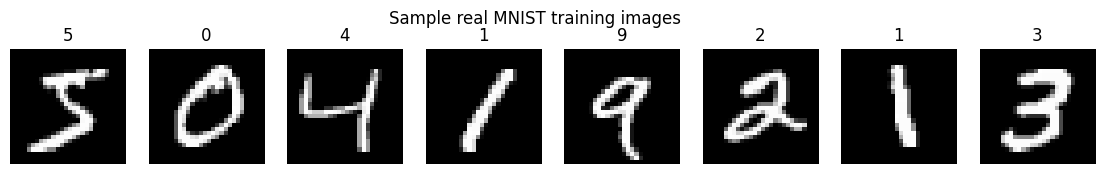

In [2]:
train_images, train_labels, test_images, test_labels = verify()
train_loader, test_loader = make_dataloaders(train_images, train_labels, test_images, test_labels)

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i], cmap="gray")
    ax.set_title(str(train_labels[i]))
    ax.axis("off")
plt.suptitle("Sample real MNIST training images")
plt.show()

## 2. Train the baseline CNN

In [3]:
model = EdgeDigitCNN()
history = train_baseline(model, train_loader, epochs=4, lr=1e-3)
baseline_acc = evaluate_accuracy(model, test_loader)
baseline_params = count_parameters(model)
torch.save(model.state_dict(), BASELINE_MODEL_PATH)
print(f"Baseline test accuracy: {baseline_acc:.4f}, params: {baseline_params}")

Epoch 1/4: loss=0.3708, acc=0.9038


Epoch 2/4: loss=0.0824, acc=0.9758


Epoch 3/4: loss=0.0600, acc=0.9822


Epoch 4/4: loss=0.0493, acc=0.9853


Baseline test accuracy: 0.9842, params: 26746


## 3. Export baseline to ONNX and benchmark in the real edge runtime

In [4]:
from src.export import export_to_onnx, load_onnx_session, evaluate_onnx_accuracy
from src.benchmark import model_size_on_disk_kb, benchmark_onnx_latency, estimate_power_draw

export_to_onnx(model, BASELINE_ONNX_PATH)
baseline_session = load_onnx_session(BASELINE_ONNX_PATH)
X_test_np = (test_images.astype(np.float32) / 255.0)[:, None, :, :]
y_test_np = test_labels.astype(np.int64)

baseline_onnx_acc = evaluate_onnx_accuracy(BASELINE_ONNX_PATH, X_test_np, y_test_np)
baseline_latency = benchmark_onnx_latency(baseline_session, X_test_np)
baseline_size_kb = model_size_on_disk_kb(BASELINE_ONNX_PATH)

print(f"ONNX Runtime accuracy: {baseline_onnx_acc:.4f}")
print(f"ONNX Runtime latency: {baseline_latency}")
print(f"Size on disk: {baseline_size_kb} KB")

ONNX Runtime accuracy: 0.9842
ONNX Runtime latency: {'mean_ms': 0.0245, 'median_ms': 0.02459, 'p95_ms': 0.04424, 'std_ms': 0.00973, 'fps': 40813.7, 'measurement_method': 'block-timed mean over 500 sequential calls (see docstring); std/median/p95 from a separate 50-call per-call-timed sample'}
Size on disk: 105.8 KB


## 4. Pruning

Pruning removes the smallest-magnitude *individual weights* per layer (not whole
filters, and not a uniform shrink of the network) -- see `src/prune.py` for the full
explanation. We apply 50% L1 unstructured pruning and check accuracy both immediately
after pruning (before recovery) and after a short fine-tuning pass.

In [5]:
import copy
from src.prune import apply_unstructured_pruning, make_pruning_permanent, compute_sparsity

pruned_model = copy.deepcopy(model)
apply_unstructured_pruning(pruned_model, amount=0.5)
sparsity_report = compute_sparsity(pruned_model)
print("Sparsity report:", sparsity_report)

pruned_acc_before = evaluate_accuracy(pruned_model, test_loader)
print(f"\nAccuracy immediately after pruning (before fine-tuning): {pruned_acc_before:.4f}")

fine_tune(pruned_model, train_loader, epochs=1, lr=1e-4)
pruned_acc_after = evaluate_accuracy(pruned_model, test_loader)
print(f"Accuracy after 1-epoch fine-tuning recovery: {pruned_acc_after:.4f}")

make_pruning_permanent(pruned_model)

Sparsity report: {'per_layer': {'conv1': {'n_zeros': 36, 'n_total': 72, 'sparsity_pct': 50.0}, 'conv2': {'n_zeros': 576, 'n_total': 1152, 'sparsity_pct': 50.0}, 'fc1': {'n_zeros': 12544, 'n_total': 25088, 'sparsity_pct': 50.0}, 'fc2': {'n_zeros': 160, 'n_total': 320, 'sparsity_pct': 50.0}}, 'overall_sparsity_pct': 50.0}



Accuracy immediately after pruning (before fine-tuning): 0.5436


Accuracy after 1-epoch fine-tuning recovery: 0.9779


EdgeDigitCNN(
  (quant): QuantStub()
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=32, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=32, out_features=10, bias=True)
  (dequant): DeQuantStub()
)

## 5. Quantization

Quantization converts FP32 weights/activations to INT8 -- see `src/quantize.py` for the
full plain-language explanation and why static (not dynamic) PTQ was chosen for this
Conv2d-heavy model.

In [6]:
from src.quantize import prepare_for_static_quantization, calibrate, convert_to_int8

model_for_quant = copy.deepcopy(model)
prepared = prepare_for_static_quantization(model_for_quant)
calibrate(prepared, train_loader, n_batches=20)
quantized_model = convert_to_int8(prepared)
quantized_acc = evaluate_accuracy(quantized_model, test_loader)
print(f"PyTorch static-PTQ INT8 accuracy: {quantized_acc:.4f} (baseline was {baseline_acc:.4f})")

/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  super().__init__(


/usr/local/lib/python3.12/dist-packages/torch/ao/nn/quantized/modules/utils.py:78: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/quantized/Quantizer.cpp:111.)
  qweight = torch.quantize_per_channel(


PyTorch static-PTQ INT8 accuracy: 0.9837 (baseline was 0.9842)


## 6. Export the quantized & combined variants to ONNX and benchmark in the real runtime

(See `src/export.py` for why we use ONNX Runtime's own quantizer on the exported graph
rather than exporting PyTorch's natively-quantized model directly.)

In [7]:
from src.export import quantize_onnx_dynamic_int8

pruned_onnx_path = MODELS_DIR / "pruned_finetuned_nb.onnx"
export_to_onnx(pruned_model, pruned_onnx_path)

baseline_int8_path = MODELS_DIR / "baseline_int8_nb.onnx"
quantize_onnx_dynamic_int8(BASELINE_ONNX_PATH, baseline_int8_path)

combined_path = MODELS_DIR / "combined_nb.onnx"
quantize_onnx_dynamic_int8(pruned_onnx_path, combined_path)

results = {}
for name, path in [("Baseline", BASELINE_ONNX_PATH), ("Pruned", pruned_onnx_path),
                    ("Quantized", baseline_int8_path), ("Combined", combined_path)]:
    session = load_onnx_session(path)
    acc = evaluate_onnx_accuracy(path, X_test_np, y_test_np)
    latency = benchmark_onnx_latency(session, X_test_np)
    size_kb = model_size_on_disk_kb(path)
    results[name] = {"accuracy": acc, "size_kb": size_kb, "latency_ms": latency["mean_ms"]}
    print(f"{name}: accuracy={acc:.4f}, size={size_kb}KB, latency={latency['mean_ms']:.4f}ms")

Baseline: accuracy=0.9842, size=105.8KB, latency=0.0238ms
Pruned: accuracy=0.9779, size=105.8KB, latency=0.0219ms


Quantized: accuracy=0.9841, size=32.03KB, latency=0.0985ms


Combined: accuracy=0.9776, size=32.03KB, latency=0.0957ms


## 7. Comparison table and trade-off visualization

In [8]:
import pandas as pd
df = pd.DataFrame(results).T
df["size_reduction_pct"] = round((1 - df["size_kb"] / df.loc["Baseline", "size_kb"]) * 100, 2)
df

,accuracy,size_kb,latency_ms,size_reduction_pct
Baseline,0.9842,105.80,0.02378,0.00
Pruned,0.9779,105.80,0.02185,0.00
Quantized,0.9841,32.03,0.09848,69.73
Combined,0.9776,32.03,0.09569,69.73


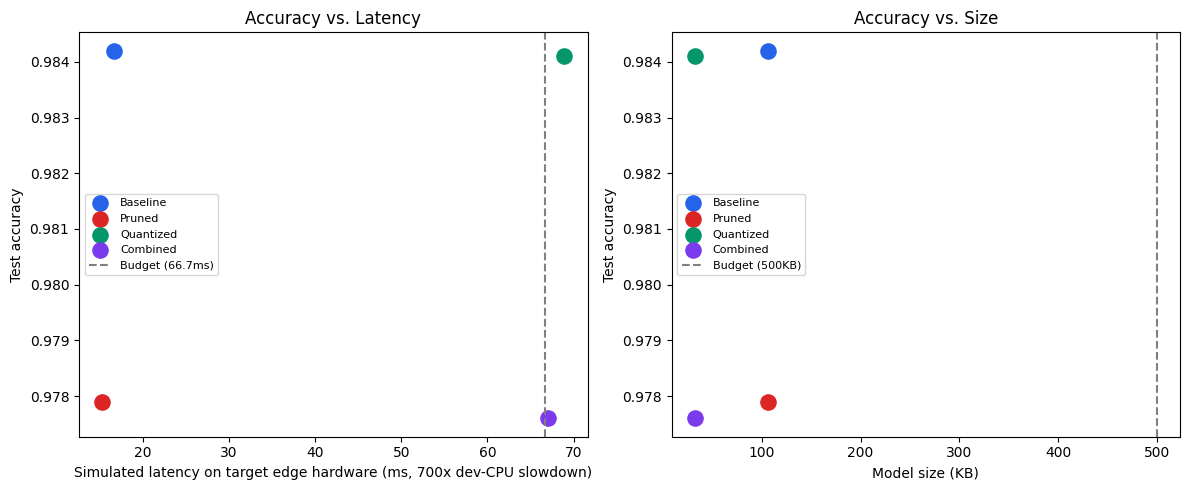

In [9]:
from src.deployment_check import simulate_target_hardware_latency_ms, LATENCY_BUDGET_MS, SIZE_BUDGET_KB

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#2563eb", "#dc2626", "#059669", "#7c3aed"]
for (name, row), color in zip(df.iterrows(), colors):
    sim_latency = simulate_target_hardware_latency_ms(row["latency_ms"])
    axes[0].scatter(sim_latency, row["accuracy"], s=120, color=color, label=name)
    axes[1].scatter(row["size_kb"], row["accuracy"], s=120, color=color, label=name)

axes[0].axvline(LATENCY_BUDGET_MS, linestyle="--", color="gray", label=f"Budget ({LATENCY_BUDGET_MS}ms)")
axes[0].set_xlabel("Simulated latency on target edge hardware (ms, 700x dev-CPU slowdown)")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Accuracy vs. Latency")
axes[0].legend(fontsize=8)

axes[1].axvline(SIZE_BUDGET_KB, linestyle="--", color="gray", label=f"Budget ({SIZE_BUDGET_KB}KB)")
axes[1].set_xlabel("Model size (KB)")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Accuracy vs. Size")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Deployment readiness check

See `ANALYSIS.md` for the full reasoning behind the final recommendation, including why the
Quantized-alone variant is preferred over Combined despite their simulated latencies being
within measurement noise of each other.

In [10]:
from src.deployment_check import check_deployment_readiness

for name, row in df.iterrows():
    result = check_deployment_readiness(name, row["accuracy"], row["size_kb"], row["latency_ms"], df.loc["Baseline", "accuracy"])
    status = "READY" if result["deployment_ready"] else "NOT READY"
    print(f"{name}: {status} (simulated latency={result['simulated_latency_ms_on_target_edge_hardware']}ms, "
          f"accuracy_drop={result['accuracy_drop_pct_vs_baseline']}pp)")

print("\nFinal recommendation: Quantized (INT8, from baseline) -- see ANALYSIS.md for full justification.")

Baseline: READY (simulated latency=16.646ms, accuracy_drop=0.0pp)
Pruned: READY (simulated latency=15.295ms, accuracy_drop=0.63pp)
Quantized: NOT READY (simulated latency=68.936ms, accuracy_drop=0.01pp)
Combined: NOT READY (simulated latency=66.983ms, accuracy_drop=0.66pp)

Final recommendation: Quantized (INT8, from baseline) -- see ANALYSIS.md for full justification.
